https://drive.google.com/file/d/11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe/view?usp=sharing --- тут лежит датасет который мы будем использовать. \
Мы хотим обучить наш unet на небольшом датасете. Нужно заполнить репорт и сделать выводы. Чтобы успеть сделать много экспериментов нужна видеокарта. Можно использовать colab, тут есть бесплатные gpu ресурсы --- так будет быстрее.

  * Сделать train/test split (или кросс-валидацию), зафиксировать все сиды, чтобы более-менее воспроизводились результаты. Добавить метрику jaccard index. Переобучиться на одном батче (например, 4 картинки), попробовать получить почти идеальное качество, посмотреть, получилось или нет. Посчитать метрики для батча и для теста. Обучить на всем train, построить train/val кривые для loss и для jaccard index, подобрать оптимальное время обучения (количество шагов) для фиксированных параметров. Визуализировать topN самых плохих предсказаний.
  * Попробовать улучшить качество не меняя архитектуру: аугментации, гиперпараметры. Сделать test time аугментации через horizontal flip, посмотреть улучшается ли что-то.
  * Попробовать улучшить качество изменяя архитектуру.
 * (+2 балла) Сделать train/test разбиение. Внутри train сделать 5fold, обучить 5 моделей. Построить кривые обучения для каждого фолда. Предсказать тест со всех 5 моделей и сагрегировать предсказания (до расчета метрик), сравнить с одной моделью обученной на всех данных. Сравнить с моделями обученными на фолдах. Сравнить плохие предсказания теста на разных фолдах. Ошибается на одних и тех же семплах или на разных?
 * (+3 балла) Сделать unet с pretrained энкодером (можно взять vgg или resnet18/34), сравнить с предыдущими пунктами.

In [ ]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
device = "cuda"

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


##Датасет

In [ ]:
!pip install -q gdown

In [ ]:
!gdown 11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe -O dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe
From (redirected): https://drive.google.com/uc?id=11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe&confirm=t&uuid=5b9496b4-6b43-4d75-84c2-781957461a62
To: /content/dataset.zip
100% 154M/154M [00:02<00:00, 73.0MB/s]


In [ ]:
!unzip dataset.zip -d /content/dataset

In [ ]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)
    print(files[:5])
    print('---')

/content/dataset
[]
---
/content/dataset/dataset
[]
---
/content/dataset/dataset/masks
['1803271743-00000327.png', '1803260054-00000076.png', '1803290444-00000528.png', '1803262023-00000569.png', '1803250018-00000427.png']
---
/content/dataset/dataset/images
['1803280908-00000049.jpg', '1803242010-00000066.jpg', '1803250018-00000113.jpg', '1803261336-00000041.jpg', '1803252014-00000510.jpg']
---


In [ ]:
import os
import random
import numpy as np
from glob import glob

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.transforms import functional
from torchvision import io
import torchvision.transforms as transforms
from torch import nn


###Фиксируем сиды

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
image_paths = sorted(glob('/content/dataset/dataset/images/*'))
mask_paths = sorted(glob('/content/dataset/dataset/masks/*'))

print(len(image_paths))
print(len(mask_paths))

2000
2000


###Проверяем картинку и маску

(800, 600, 3)
(800, 600)


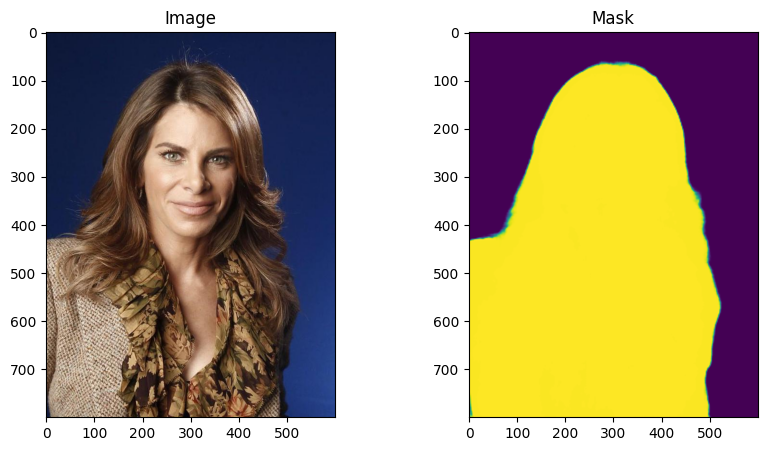

In [ ]:
idx = 0

image = cv2.imread(image_paths[idx])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_paths[idx], 0)

print(image.shape)
print(mask.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Image')

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title('Mask')

plt.show()

In [ ]:
image_prepare = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

class SegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, images, masks, transform=image_prepare):
        self.images = images
        self.masks = masks

        assert len(self.images) == len(self.masks)

        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, item):
        img = self.transform(io.read_image(str(self.images[item])))
        mask = self.transform(io.read_image(str(self.masks[item])))
        return img, mask

In [ ]:
train_size = int(len(image_paths) * 0.8)

val_dataset = SegmentationDataset(images=image_paths[train_size:], masks=mask_paths[train_size:])
train_dataset = SegmentationDataset(images=image_paths[:train_size], masks=mask_paths[:train_size])

In [ ]:
print("Train size:", len(train_dataset))
print("Test size:", len(val_dataset))

Train size: 1600
Test size: 400


###Построение UNET

In [ ]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        super(CNNBlock, self).__init__()

        self.seq_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        return self.seq_block(x)

class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding):
          super(CNNBlocks, self).__init__()

          self.layers = nn.ModuleList()
          for _ in range(n_conv):
              self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
              in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(Encoder, self).__init__()

        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [CNNBlocks(n_conv=2,
                                          in_channels=in_channels,
                                          out_channels=out_channels,
                                          padding=padding),
                                nn.MaxPool2d(2, 2)
                                ]

            in_channels = out_channels
            out_channels = 2 * out_channels

        self.enc_layers.append(CNNBlocks(n_conv=2,
                                         in_channels=in_channels,
                                         out_channels=out_channels,
                                         padding=padding
                                         ))

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(Decoder, self).__init__()

        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for i in range(n_up):
            self.layers += [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                            CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding)]

            in_channels //= 2
            out_channels //= 2

        self.layers.append(nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0))

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                dim_4 = connections_current.size(3) - x.size(3)
                dim_3 = connections_current.size(2) - x.size(2)
                if dim_4 != 0 or dim_3 != 0:
                    x = nn.functional.pad(x, [0, dim_4, 0, dim_3])
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x

class UNET(nn.Module):
    def __init__(self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1):
        super(UNET, self).__init__()
        self.encoder = Encoder(in_channels, first_out_channels, padding=padding, n_down=n_down)
        self.decoder = Decoder(first_out_channels * (2 ** n_down),
                               first_out_channels * (2 ** (n_down - 1)),
                               exit_channels, padding=padding, n_up=n_down)

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

##Обучение

In [45]:
#!pip install torchmetrics
import torchmetrics

jaccard = torchmetrics.classification.BinaryJaccardIndex().to(device)
def jaccard_metric(pred, y):
    return jaccard(pred, y > jaccard.threshold)

##Переобучение на одном батче

In [ ]:
overfit_batch = next(iter(DataLoader(train_dataset, batch_size=4, shuffle=False)))
images, masks = overfit_batch
images, masks = images.to(device), masks.to(device)

model = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
def plot_results(history):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_jaccard'], label='Train Jaccard')
    plt.plot(history['val_jaccard'], label='Val Jaccard')
    plt.title('Jaccard Index per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('IoU Score')
    plt.grid(True)
    plt.legend()

    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def train(model, opt, loader):
    model.train()
    train_losses = []
    train_iou = []
    for img_batch, mask_batch in tqdm(loader):
          img_batch, mask_batch = img_batch.to(device), mask_batch.to(device)
          pred = model(img_batch)
          loss = criterion(pred, mask_batch)

          iou = jaccard_metric(pred, mask_batch)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          train_losses.append(loss.item())
          train_iou.append(iou.item())
    avg_train_loss = np.mean(train_losses)
    avg_train_iou = np.mean(train_iou)
    return model, opt, avg_train_loss, avg_train_iou

In [ ]:
def val(model, loader):
  model.eval()
  val_losses = []
  val_iou = []
  with torch.no_grad():
        for img_batch, mask_batch in tqdm(loader):
            img_batch, mask_batch = img_batch.to(device), mask_batch.to(device)
            pred = model(img_batch)
            loss = criterion(pred, mask_batch)
            iou = jaccard_metric(pred, mask_batch)

            val_losses.append(loss.item())
            val_iou.append(iou.item())
        avg_val_loss = np.mean(val_losses)
        avg_val_iou = np.mean(val_iou)
        return avg_val_loss, avg_val_iou

In [ ]:
def main_loop(
    model,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=10):
    history = {
          'train_loss': [], 'val_loss': [],
          'train_jaccard': [], 'val_jaccard': []
          }
    for epoch in range(num_epochs):
        model, optimizer, avg_train_loss, avg_train_iou = train(model, optimizer, train_loader)
        avg_val_loss, avg_val_iou = val(model, val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_jaccard'].append(avg_train_iou)
        history['val_jaccard'].append(avg_val_iou)
        print(f"Epoch {epoch+1:02d}: Loss(T/V): {avg_train_loss:.4f}/{avg_val_loss:.4f} | Jaccard(T/V): {avg_train_iou:.4f}/{avg_val_iou:.4f}")
    plot_results(history)

    return model, optimizer, history

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 01: Loss(T/V): 0.6677/0.6965 | Jaccard(T/V): 0.4757/0.0000


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 49: Loss(T/V): 0.2415/0.6858 | Jaccard(T/V): 0.9904/0.4097


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 50: Loss(T/V): 0.2391/0.6796 | Jaccard(T/V): 0.9910/0.4170


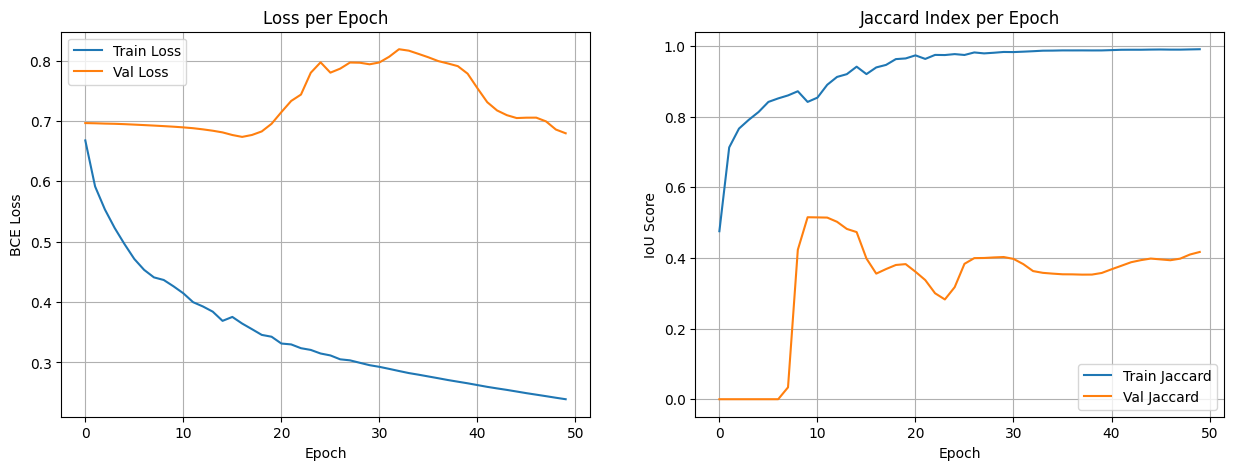

In [ ]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(train_dataset, range(batch_size)),
    batch_size=batch_size,
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(val_dataset, range(batch_size)),
    batch_size=batch_size,
)

model = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters())
model, _, _ = main_loop(
    model, optimizer, train_loader, val_loader,
    num_epochs=50
)

In [ ]:
def calculate_final_metrics(model, batch_data, val_loader, metric, device):
    model.eval()
    images_b, masks_b = batch_data
    images_b, masks_b = images_b.to(device), masks_b.to(device)

    # 1. Метрики для переобученного батча
    with torch.no_grad():
        out_b = model(images_b)
        batch_loss = criterion(out_b, masks_b).item()
        batch_iou = metric(torch.sigmoid(out_b), masks_b.int()).item()

    # 2. Метрики для всего теста
    avg_test_loss, avg_test_iou = val(val_loader)

    print("-" * 30)
    print(f"OVERFIT BATCH: Loss = {batch_loss:.6f}, Jaccard = {batch_iou:.4f}")
    print(f"TEST SET:      Loss = {avg_test_loss:.6f}, Jaccard = {avg_test_iou:.4f}")
    print("-" * 30)

calculate_final_metrics(model, overfit_batch, val_loader, jaccard_metric, device)

  0%|          | 0/1 [00:00<?, ?it/s]

------------------------------
OVERFIT BATCH: Loss = 0.055325, Jaccard = 0.7114
TEST SET:      Loss = 1.527729, Jaccard = 0.3554
------------------------------


Видим, что на батче получилось пости идеальное качество, а на тесте все очень плохо

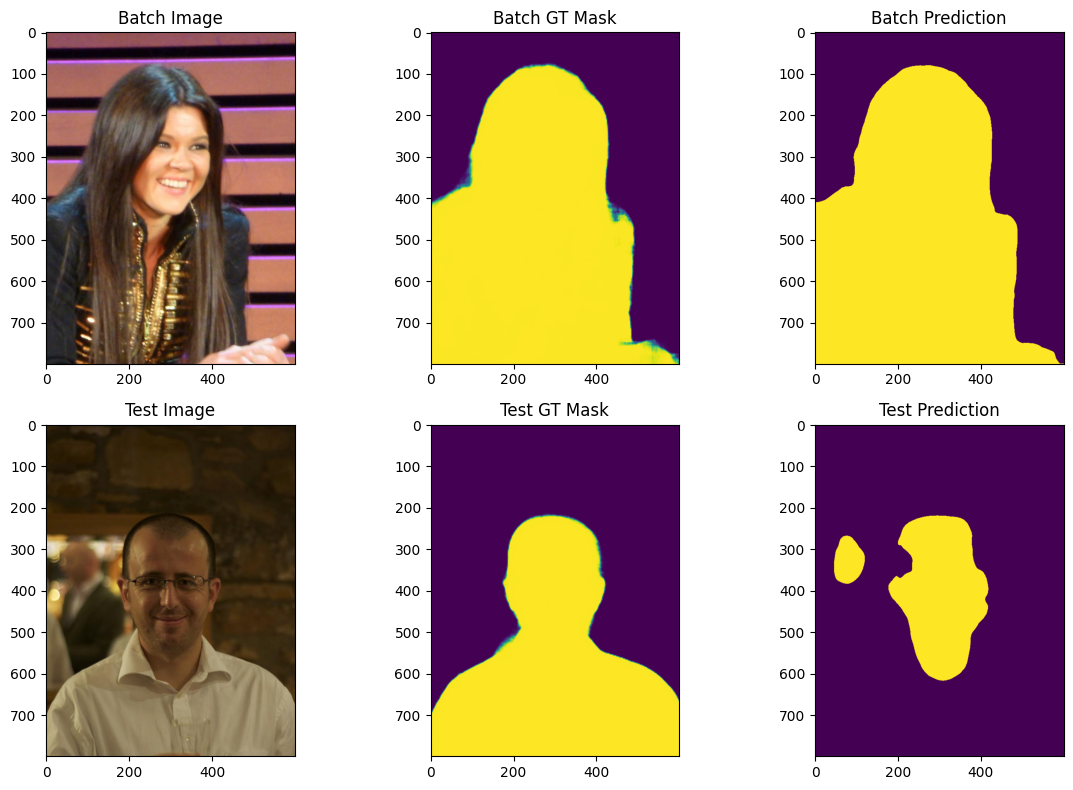

In [ ]:
import matplotlib.pyplot as plt

def visualize_results(model, batch_data, val_dataset, device):
    model.eval()
    imgs_b, msks_b = batch_data
    test_img, test_mask = val_dataset[0]

    with torch.no_grad():
        pred_b = torch.sigmoid(model(imgs_b.to(device))).cpu()
        pred_t = torch.sigmoid(model(test_img.unsqueeze(0).to(device))).cpu()

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))

    # Визуализация для батча
    axs[0, 0].imshow(imgs_b[0].permute(1, 2, 0).cpu().numpy())
    axs[0, 0].set_title("Batch Image")
    axs[0, 1].imshow(msks_b[0].squeeze().cpu().numpy())
    axs[0, 1].set_title("Batch GT Mask")
    axs[0, 2].imshow(pred_b[0].squeeze().cpu().numpy() > 0.5)
    axs[0, 2].set_title("Batch Prediction")

    # Визуализация для тестового изображения
    axs[1, 0].imshow(test_img.permute(1, 2, 0).cpu().numpy())
    axs[1, 0].set_title("Test Image")
    axs[1, 1].imshow(test_mask.squeeze().cpu().numpy())
    axs[1, 1].set_title("Test GT Mask")
    axs[1, 2].imshow(pred_t[0].squeeze().cpu().numpy() > 0.5)
    axs[1, 2].set_title("Test Prediction")

    plt.tight_layout()
    plt.show()

visualize_results(model, overfit_batch, val_dataset, device)

На Test Prediction случайные пятна, то есть модель выучила 4 картинки, а остальные сегментировать не может

###Обучимся на всем датасете

In [ ]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
model = UNET(in_channels=3, first_out_channels=64, exit_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 25
model, _, _ = main_loop(
    model, optimizer, train_loader, val_loader, num_epochs
)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01: Loss(T/V): 0.6079/0.5710 | Jaccard(T/V): 0.5402/0.5912


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 24: Loss(T/V): 0.1145/0.1511 | Jaccard(T/V): 0.9194/0.8903


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 25: Loss(T/V): 0.1103/0.1322 | Jaccard(T/V): 0.9227/0.9042


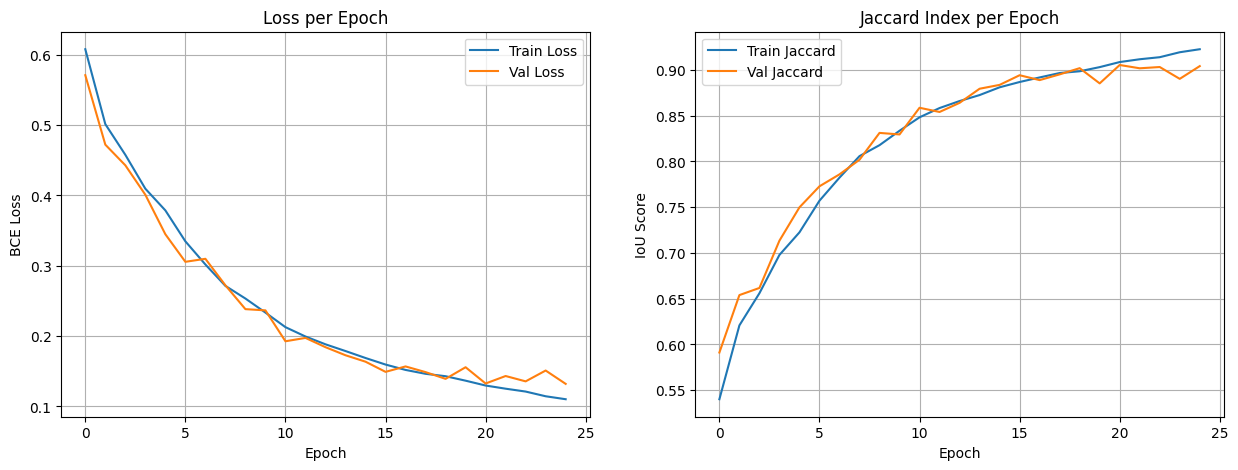

###Визуализация худших предсказаний

104

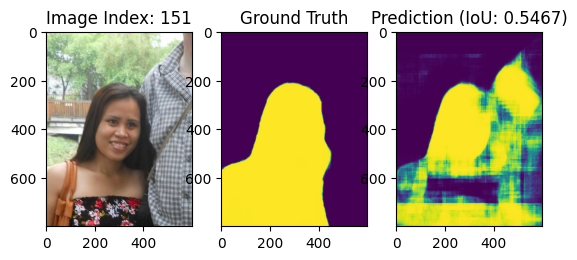

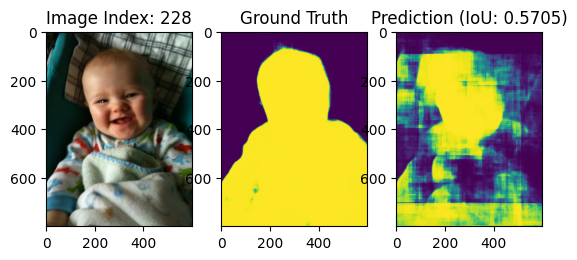

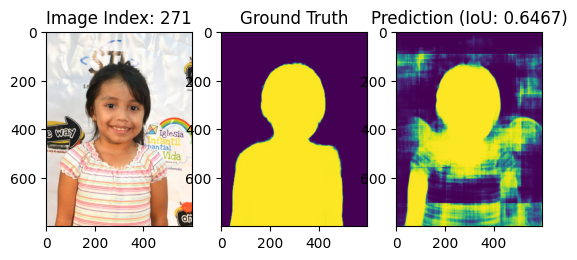

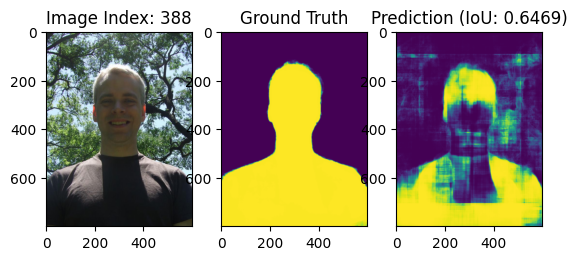

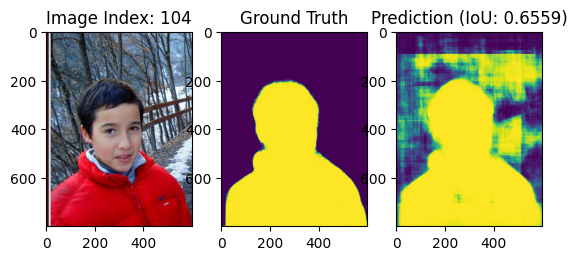

In [ ]:
def visualize_worst_predictions(n):
    val_iou = []
    with torch.no_grad():
        for i, (X, y) in enumerate(val_dataset):
            pred = model(X.to(device).unsqueeze(0))[0]
            val_iou.append((jaccard_metric(pred, y.to(device)).item(), i))

    worst_examples = sorted(val_iou)[:n]

    with torch.no_grad():
        for i, (score, idx) in enumerate(worst_examples):
            img, GTmask = val_dataset[idx]
            pred = model(img.to(device).unsqueeze(0))[0]
            mask = nn.functional.sigmoid(pred)
            fig, ax = plt.subplots(1, 3)
            ax[0].imshow(functional.to_pil_image(img))
            ax[0].set_title(f"Image Index: {idx}")
            ax[1].imshow(functional.to_pil_image(GTmask))
            ax[1].set_title(f"Ground Truth")
            ax[2].imshow(functional.to_pil_image(mask))
            ax[2].set_title(f"Prediction (IoU: {score:.4f})")


    return idx

visualize_worst_predictions(5)

##Улучшение качества без изменения архитектуры

### Аугментация

In [ ]:
augmented = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

In [ ]:
train_size = int(len(image_paths) * 0.8)

val_dataset_augmented = SegmentationDataset(images=image_paths[train_size:], masks=mask_paths[train_size:], transform=augmented)
train_dataset_augmented = SegmentationDataset(images=image_paths[:train_size], masks=mask_paths[:train_size], transform=augmented)

train_loader_augmented = torch.utils.data.DataLoader(train_dataset_augmented, batch_size=4, shuffle=True)
val_loader_augmented = torch.utils.data.DataLoader(val_dataset_augmented, batch_size=4, shuffle=True)
model = UNET(in_channels=3, first_out_channels=64, exit_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
num_epochs_augmented = 10
model, _, _ = main_loop(
    model, optimizer, train_loader_augmented, val_loader_augmented, num_epochs_augmented
)

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01: Loss(T/V): 0.3361/0.2199 | Jaccard(T/V): 0.7576/0.8461


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 09: Loss(T/V): 0.0619/0.0771 | Jaccard(T/V): 0.9588/0.9466


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 10: Loss(T/V): 0.0533/0.0687 | Jaccard(T/V): 0.9648/0.9556


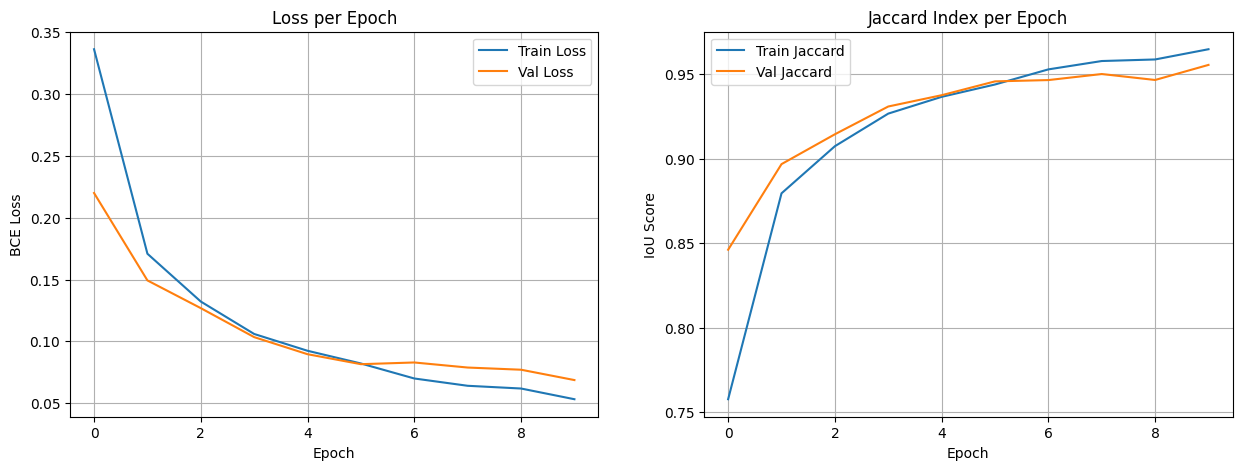

Аугментация позволила значительно улучшить результаты!

##Изменение архитектуры

In [46]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset

dataset = SegmentationDataset(images=image_paths, masks=mask_paths, transform=augmented)
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
models = []
res = []
for i, (train_index, test_index) in enumerate(kfold.split(dataset)):
    train_subset = Subset(dataset, train_index)
    test_subset = Subset(dataset, test_index)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=True, num_workers=2)

    net = UNET(in_channels=3, first_out_channels=64, exit_channels=1).to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

    net = net.cuda()

    torch.cuda.empty_cache()

    final, _, h = main_loop(net, optimizer, train_loader, test_loader)
    models.append(final)
    res.append(h)


Графики для каждой модели:

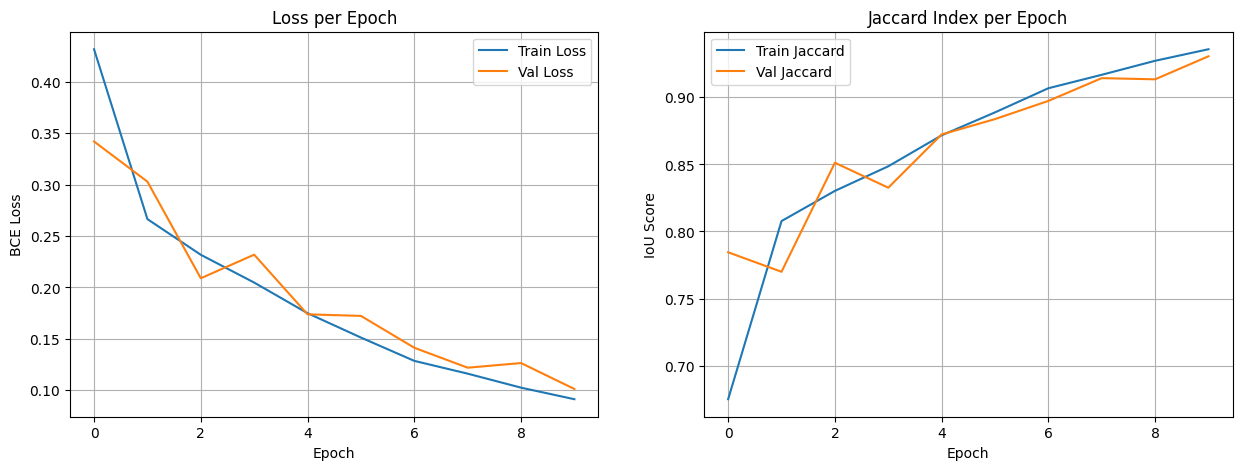

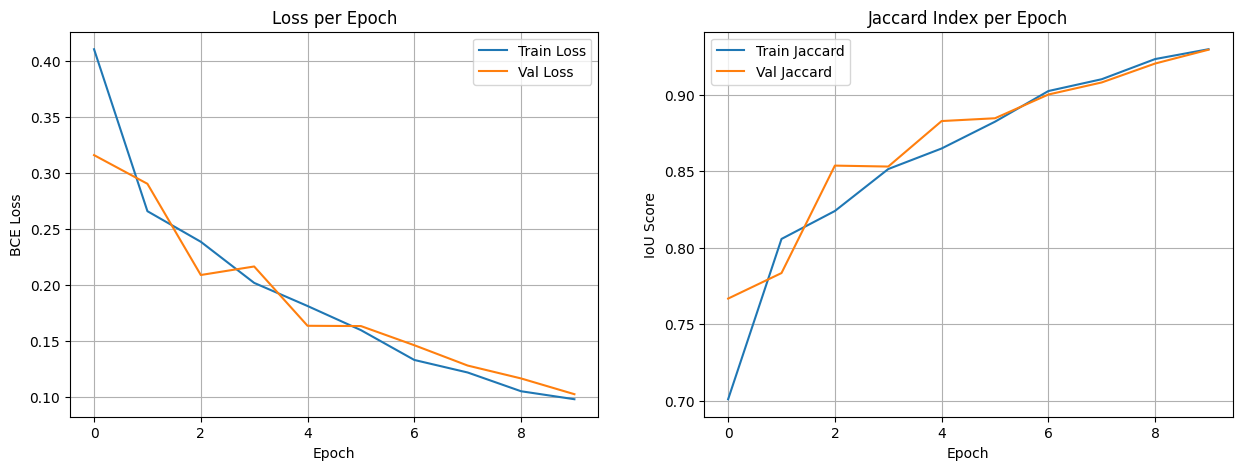

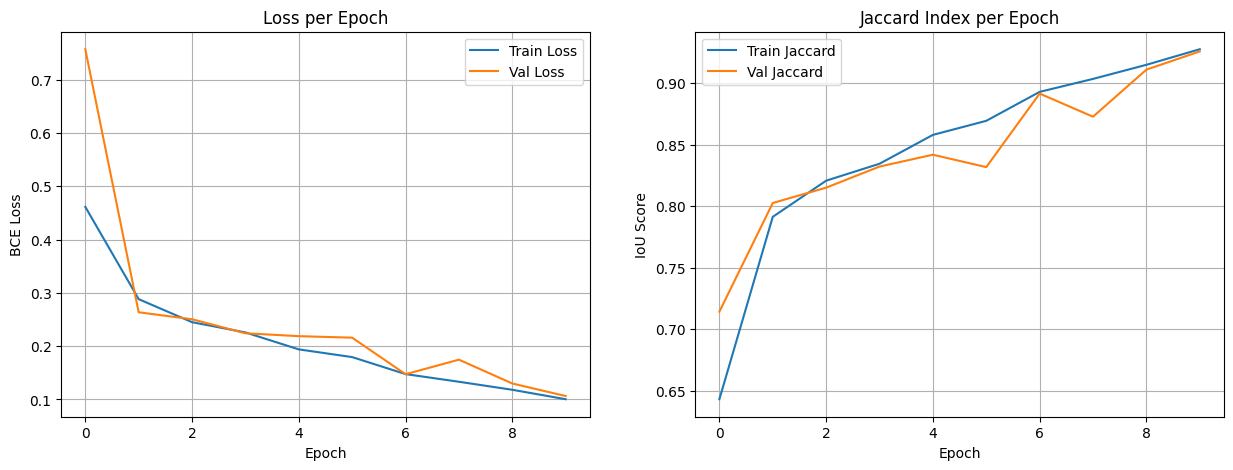

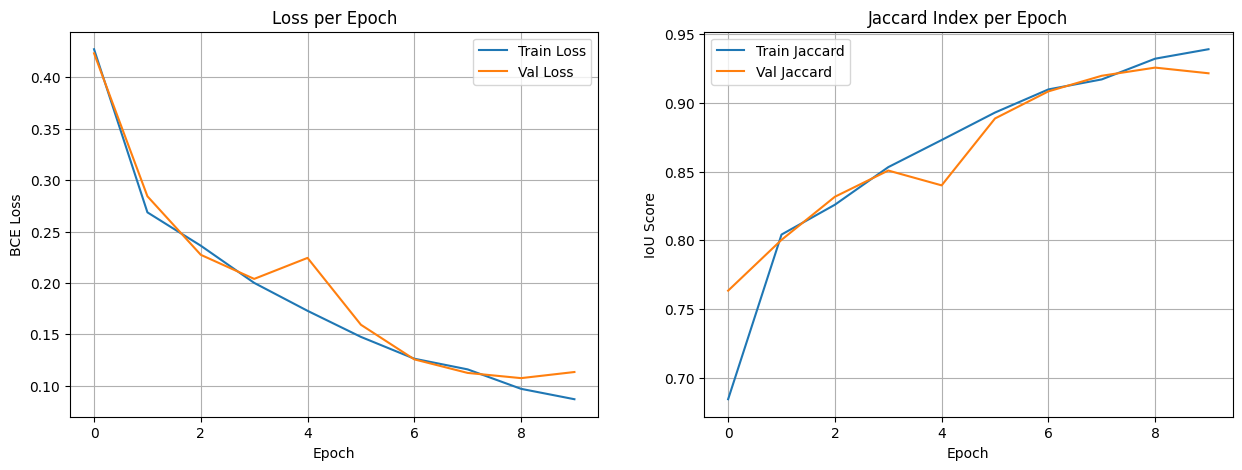

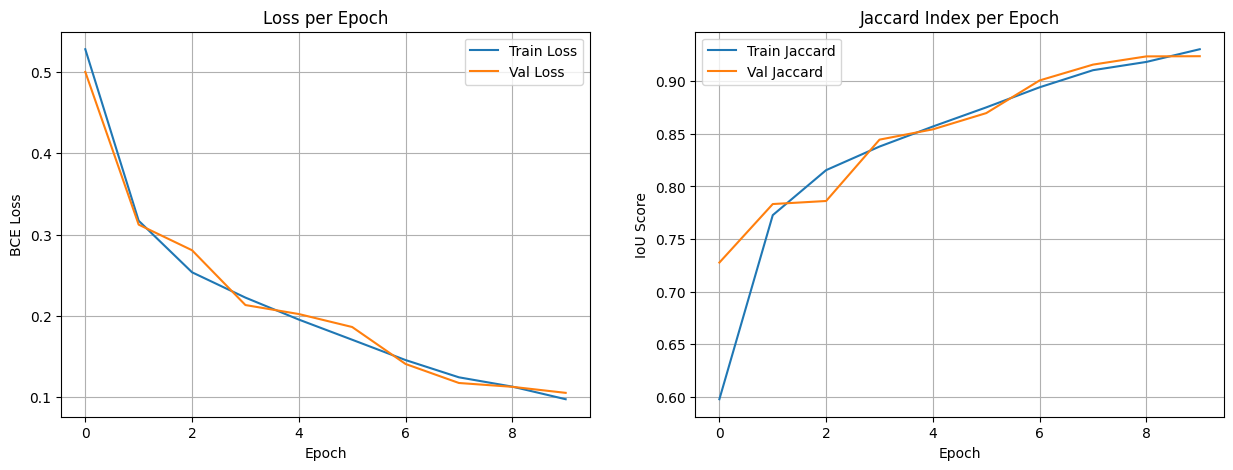

In [ ]:
for history in res:
  plot_results(history)

In [ ]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
def evaluate_ensemble(models, loader, device):

    scores = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            logits_sum = 0

            for model in models:

                model.eval()

                logits_sum += model(images)

            mean_logits = logits_sum / len(models)

            probs = torch.sigmoid(mean_logits)

            score = jaccard_metric(probs, masks)

            scores.append(score.item())

    return np.mean(scores)

In [ ]:
ensemble_score = evaluate_ensemble(
    models,
    val_loader,
    device
)

print(f"\nEnsemble Jaccard: {ensemble_score:.4f}")


Ensemble Jaccard: 0.7488


In [ ]:
print(f"IoU одиночных моделей:")
individual_ious = [h['val_jaccard'][-1] for h in res]
for iou in individual_ious:
  print(f"{iou:.4f}")

IoU одиночных моделей:
0.9306
0.9296
0.9257
0.9215
0.9237


###Худшие предсказания для каждой модели

In [ ]:
def visualize_worst_predictions(model, n):
    val_iou = []
    with torch.no_grad():
        for i, (X, y) in enumerate(val_dataset):
            pred = model(X.to(device).unsqueeze(0))[0]
            val_iou.append((jaccard_metric(pred, y.to(device)).item(), i))

    worst_examples = sorted(val_iou)[:n]

    with torch.no_grad():
        for i, (score, idx) in enumerate(worst_examples):
            img, GTmask = val_dataset[idx]
            pred = model(img.to(device).unsqueeze(0))[0]
            mask = nn.functional.sigmoid(pred)
            fig, ax = plt.subplots(1, 3)
            ax[0].imshow(functional.to_pil_image(img))
            ax[0].set_title(f"Image Index: {idx}")
            ax[1].imshow(functional.to_pil_image(GTmask))
            ax[1].set_title(f"Ground Truth")
            ax[2].imshow(functional.to_pil_image(mask))
            ax[2].set_title(f"Prediction (IoU: {score:.4f})")


    return idx

336

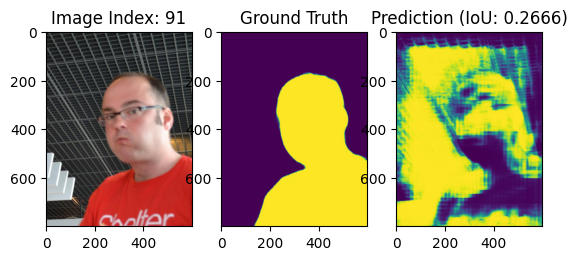

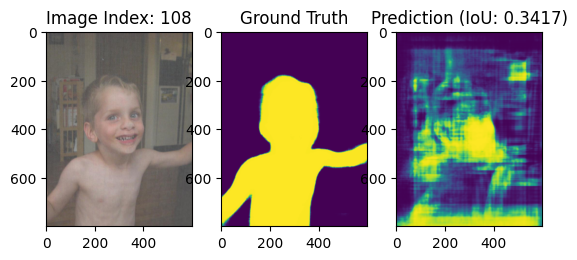

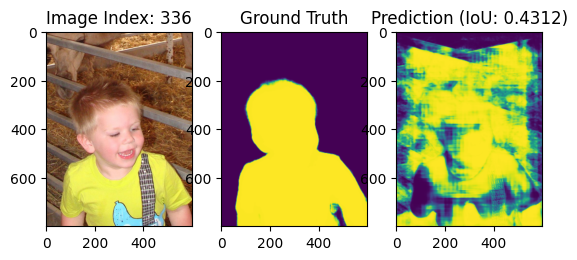

In [ ]:
visualize_worst_predictions(models[0], 3)

336

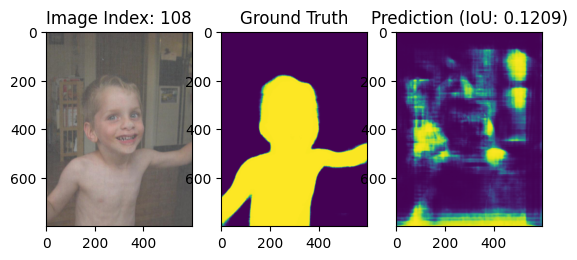

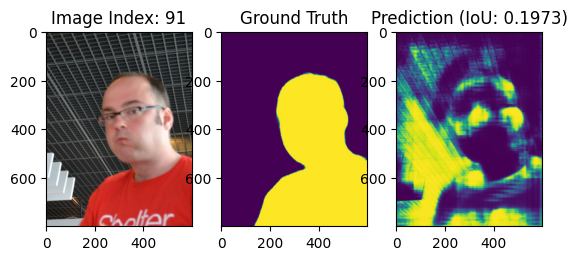

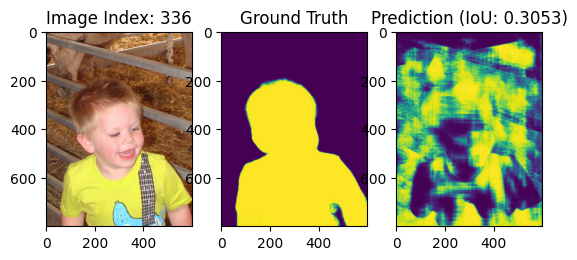

In [ ]:
visualize_worst_predictions(models[1], 3)

213

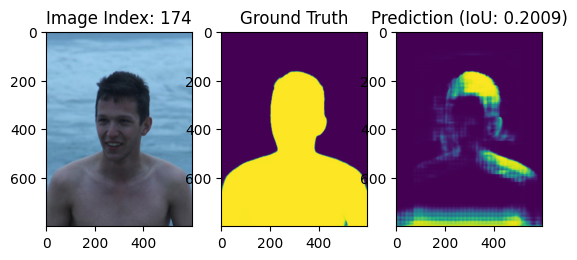

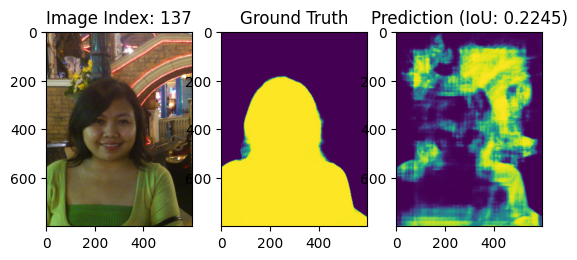

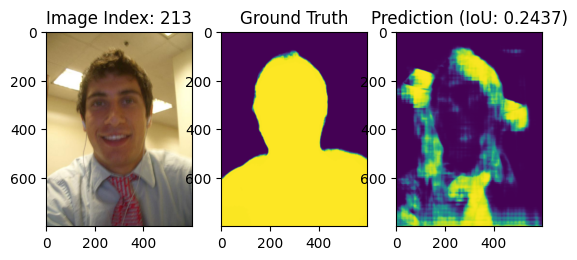

In [ ]:
visualize_worst_predictions(models[2], 3)

91

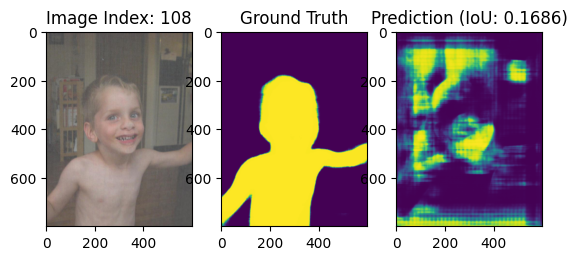

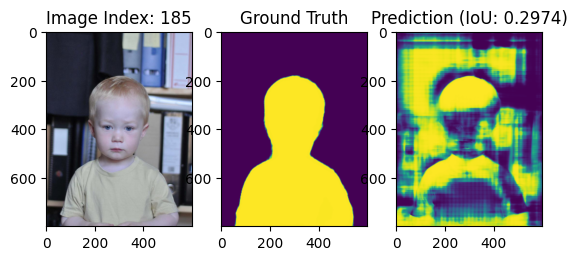

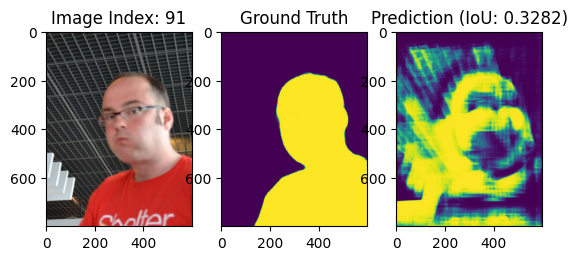

In [ ]:
visualize_worst_predictions(models[3], 3)

261

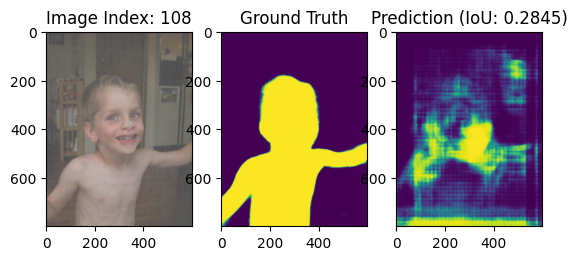

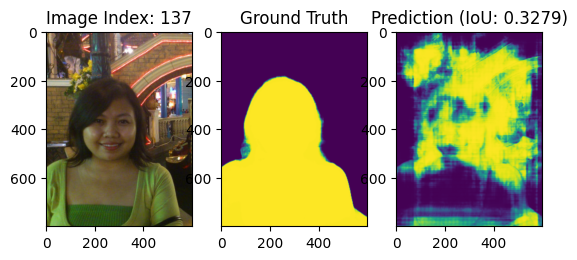

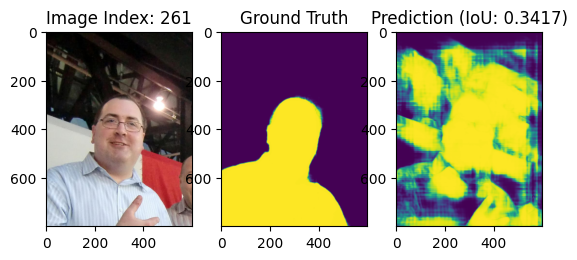

In [ ]:
visualize_worst_predictions(models[4], 3)

Худшие предсказания пересекаются

##UNET с предобученным энкодером

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels // 2 + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResNet34UNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet34(weights='IMAGENET1K_V1')
        layers = list(base_model.children())

        self.input_layer = nn.Sequential(*layers[:3]) # (64, H/2, W/2)
        self.input_pool = layers                   # (64, H/4, W/4)
        self.layer1 = layers                       # (64, H/4, W/4)
        self.layer2 = layers                       # (128, H/8, W/8)
        self.layer3 = layers                       # (256, H/16, W/16)
        self.layer4 = layers                       # (512, H/32, W/32)

        self.up4 = DecoderBlock(512, 256, 256)        # Вход: 512 -> Выход: 256
        self.up3 = DecoderBlock(256, 128, 128)        # Вход: 256 -> Выход: 128
        self.up2 = DecoderBlock(128, 64, 64)          # Вход: 128 -> Выход: 64
        self.up1 = DecoderBlock(64, 64, 64)           # Вход: 64 -> Выход: 64

        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x0 = self.input_layer(x)     # H/2
        x1_p = self.input_pool(x0)
        x1 = self.layer1(x1_p)       # H/4
        x2 = self.layer2(x1)         # H/8
        x3 = self.layer3(x2)         # H/16
        x4 = self.layer4(x3)         # H/32 (Bottom)

        d4 = self.up4(x4, x3)        # H/16
        d3 = self.up3(d4, x2)        # H/8
        d2 = self.up2(d3, x1)        # H/4
        d1 = self.up1(d2, x0)        # H/2

        out = self.final_up(d1)      # H
        return self.final_conv(out)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=True)
model = UNET(in_channels=3, first_out_channels=64, exit_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters())

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01: Loss(T/V): 0.5648/0.5165 | Jaccard(T/V): 0.5599/0.5857


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 09: Loss(T/V): 0.2700/0.2755 | Jaccard(T/V): 0.8056/0.7965


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 10: Loss(T/V): 0.2501/0.2869 | Jaccard(T/V): 0.8193/0.7789


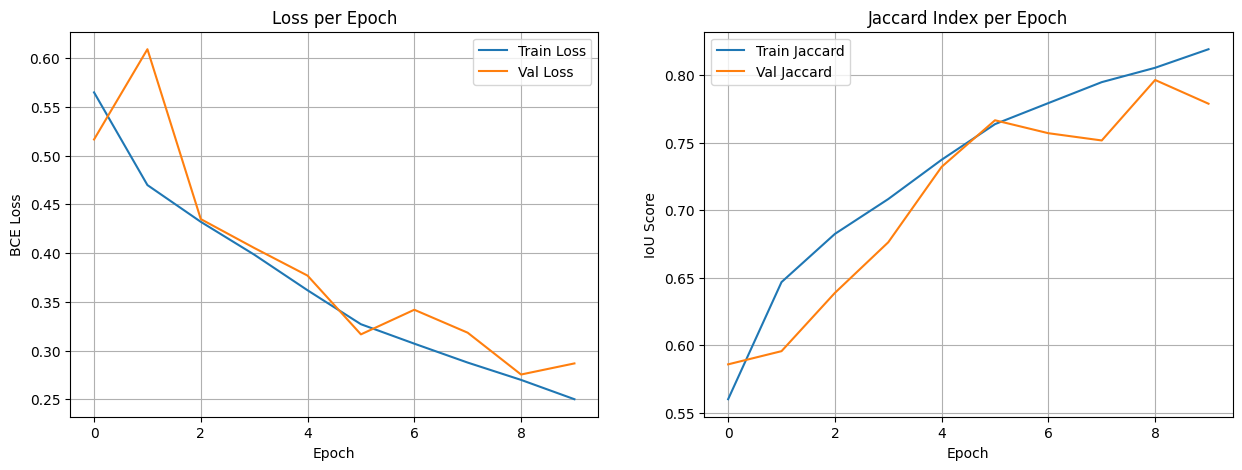

In [ ]:
model, _, _ = main_loop(model, optimizer, train_loader, val_loader)

Такая модель тоже показывает хорошие результаты